<a href="https://colab.research.google.com/github/priyadarshan189/Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Analysis
### Major Project: Seasonal Agriculture Performance Analysis


**Objective:** The primary objective of this project is to analyze agricultural data from different seasons
and identify meaningful patterns, trends, relationships and differences in agricultural
performance.

**Dataset:** `seasonal_agriculture_performance_dataset.csv`

**Author:** PRIYADARSHAN D


# **Introduction to Dataset**

The dataset represents agricultural activities carried out across different seasons,
geographical areas and farming conditions. It contains information related to farming
practices, environmental conditions, crop production, resource usage and economic
performance.
The dataset provides students with an opportunity to explore how agricultural performance
changes across seasons and to identify meaningful patterns and differences through data
analysis.

# **Problem Statement**

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

## 0. Setup — Import Libraries

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")


Libraries imported successfully.


In [5]:
from google.colab import files
uploaded = files.upload()   # choose 'seasonal_agriculture_performance_dataset.csv' when prompted


Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


In [6]:
# Load the dataset
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")


Dataset loaded successfully!
Shape: (4000, 28)


## 1. Initial Data Exploration

### 1.1 Top 5 rows

In [7]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


### 1.2 Dataset shape and structure

In [8]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())


Number of rows: 4000
Number of columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [ ]:
df.info()

### 1.3 Data types

In [9]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


### 1.4 Summary statistics (numeric columns)

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


### 1.5 Summary statistics (categorical columns)

In [11]:
df.describe(include='object').T

,count,unique,top,freq
Farm_ID,4000,4000,SF13984,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


## 2. Data Cleaning & Preparation

### 2.1 Identify missing values

In [12]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pct})
missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)


,Missing_Count,Missing_%
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


### 2.2 Handle missing values
We impute numeric columns with missing values using the **median of their respective Season group**, since agricultural metrics like rainfall, soil moisture, and yield naturally vary by season. Using a season-wise median (instead of a global median) preserves seasonal patterns instead of diluting them.


In [13]:
cols_with_na = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_with_na:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values after imputation:")
print(df.isnull().sum().sum())


Remaining missing values after imputation:
0


### 2.3 Identify and handle duplicate records

In [14]:
dup_count = df.duplicated().sum()
print(f"Number of duplicate rows: {dup_count}")

# Also check for duplicate Farm_ID (should be unique)
dup_ids = df['Farm_ID'].duplicated().sum()
print(f"Number of duplicate Farm_IDs: {dup_ids}")

df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")


Number of duplicate rows: 0
Number of duplicate Farm_IDs: 0
Shape after removing duplicates: (4000, 28)


### 2.4 Data type correction
`Farm_ID`, `State`, `District`, `Crop`, `Season`, and `Irrigation_Method` are categorical text fields — convert them to the `category` dtype for memory efficiency and cleaner grouping.


In [15]:
categorical_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']
for col in categorical_cols:
    df[col] = df[col].astype('category')

df.dtypes


,0
Farm_ID,object
State,category
District,category
Crop,category
Season,category
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


### 2.5 Outlier investigation

In [16]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

outlier_summary = pd.DataFrame({
    'Column': numeric_cols,
    'Outlier_Count': [count_outliers_iqr(df[c]) for c in numeric_cols]
}).sort_values('Outlier_Count', ascending=False)

outlier_summary


,Column,Outlier_Count
18,Profit_INR,404
14,Production_Tonnes,333
20,Water_Efficiency_t_per_1000m3,322
13,Yield_Tonnes_Ha,302
19,Water_Used_m3,276
17,Revenue_INR,240
9,Potassium_kg_ha,32
4,Sunlight_Hours_Day,26
8,Phosphorus_kg_ha,16
10,Fertilizer_kg_ha,15


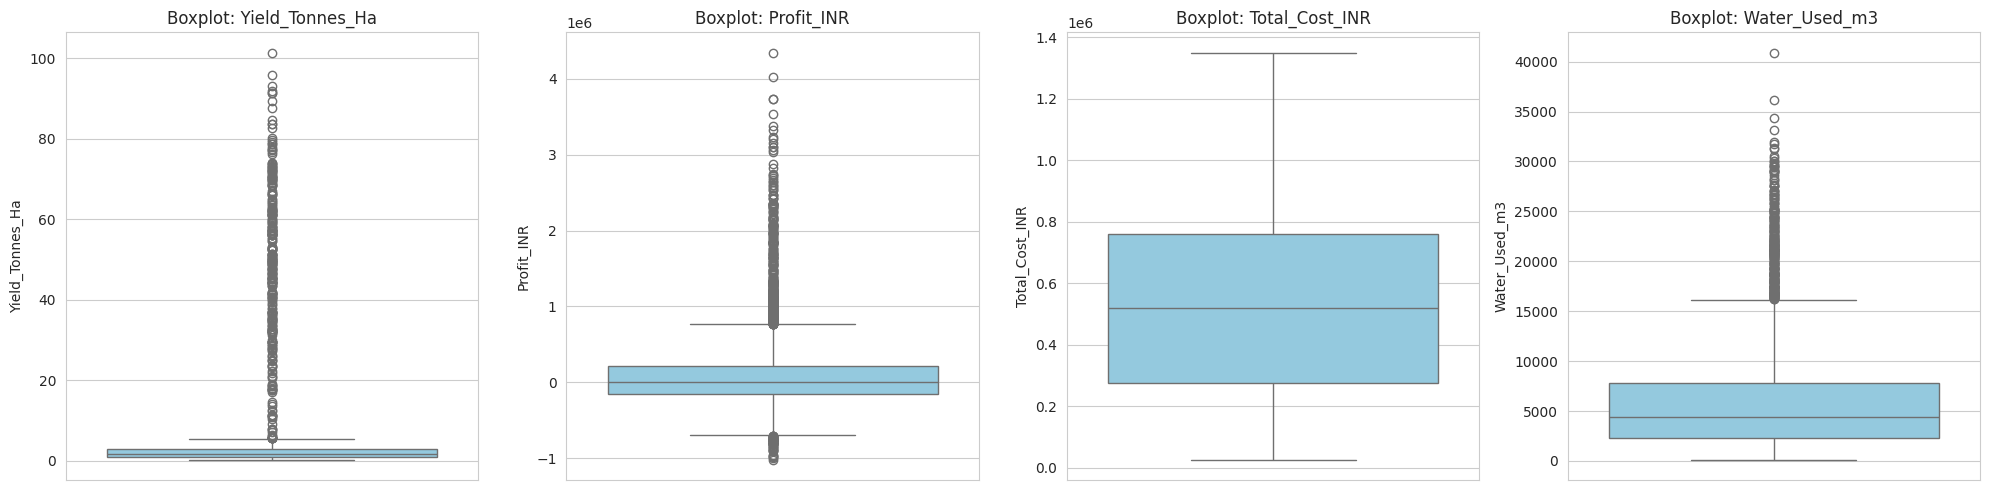

In [17]:
# Visualize outliers for key financial/yield columns using boxplots
key_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Total_Cost_INR', 'Water_Used_m3']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, key_cols):
    sns.boxplot(y=df[col], ax=ax, color='skyblue')
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()


**Note on outliers:** Extreme values in `Profit_INR` (including negative profits/losses) and `Water_Used_m3` are *realistic* in agriculture — droughts, floods, pest attacks, and price crashes genuinely produce extreme outcomes. Rather than deleting them (which would hide real seasonal risk patterns), we retain them but flag their presence, and use median-based / robust statistics where relevant later in the analysis.


## 3. Univariate Analysis

### 3.1 Distribution of numeric variables

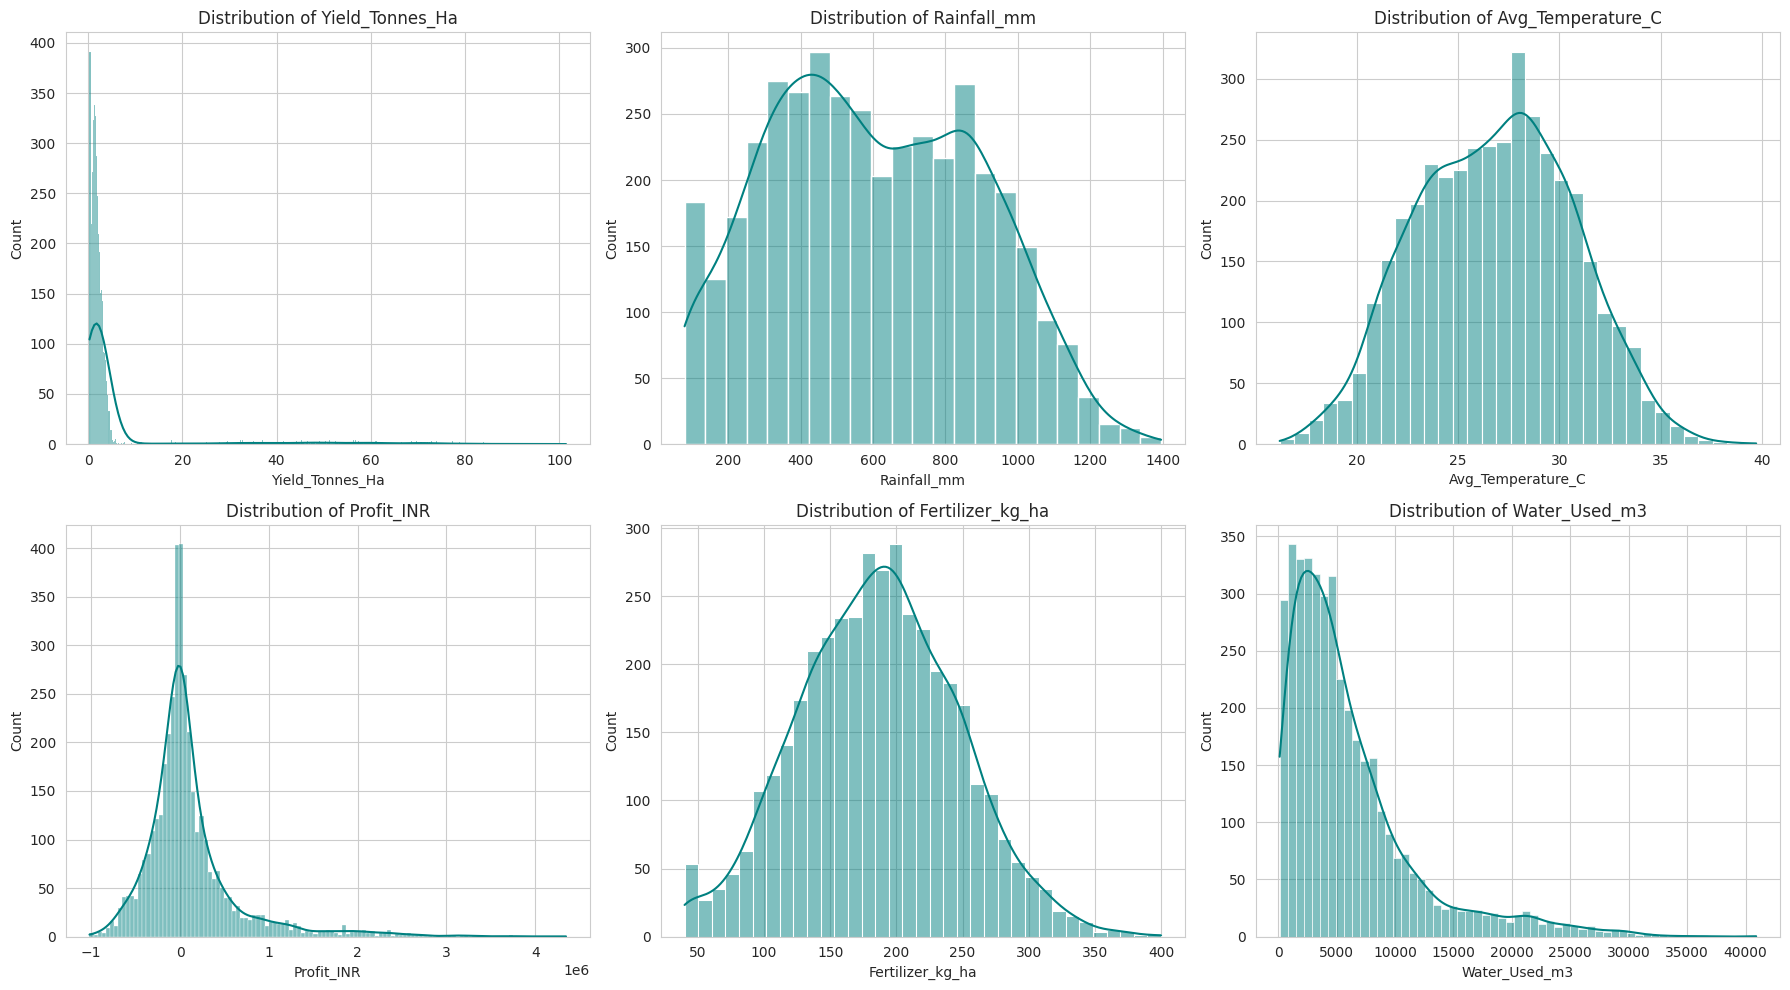

In [18]:
cols_to_plot = ['Yield_Tonnes_Ha', 'Rainfall_mm', 'Avg_Temperature_C', 'Profit_INR',
                'Fertilizer_kg_ha', 'Water_Used_m3']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, col in zip(axes, cols_to_plot):
    sns.histplot(df[col], kde=True, ax=ax, color='teal')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


### 3.2 Categorical variable counts

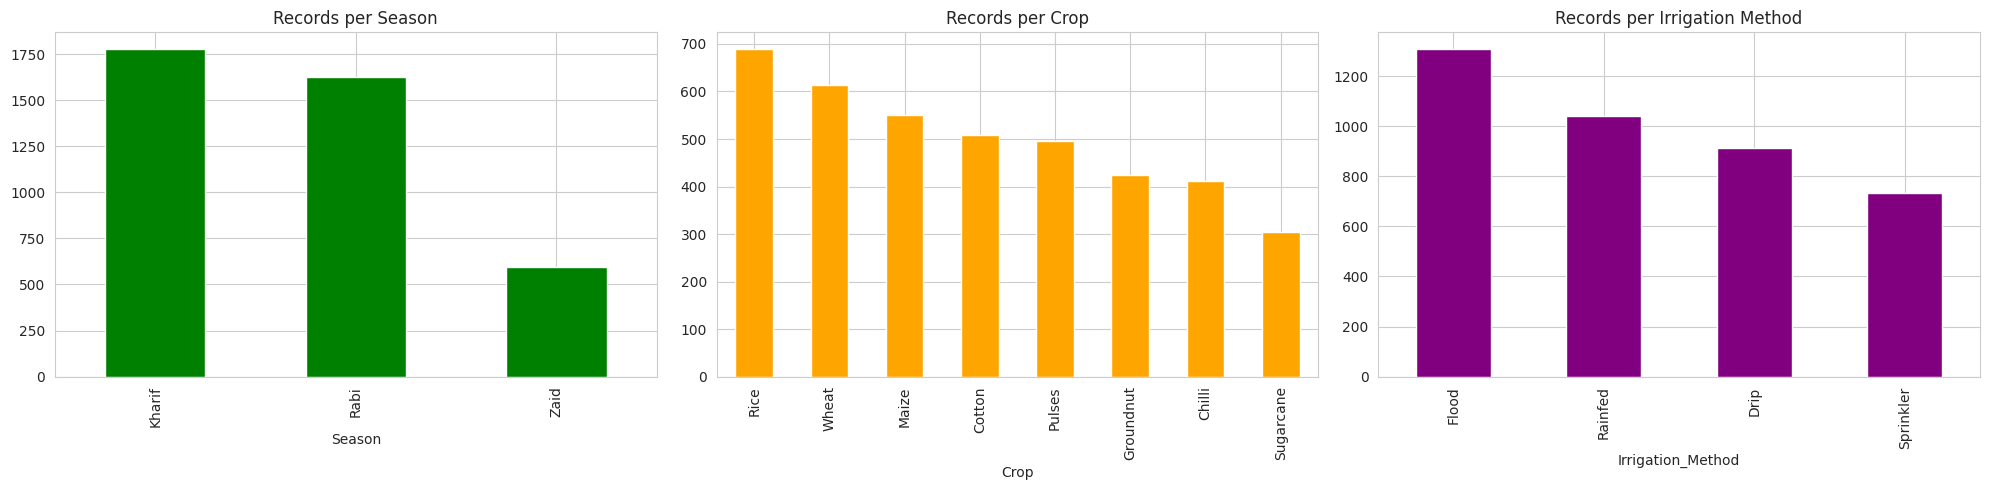

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

df['Season'].value_counts().plot(kind='bar', ax=axes[0], color='green')
axes[0].set_title('Records per Season')

df['Crop'].value_counts().plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Records per Crop')

df['Irrigation_Method'].value_counts().plot(kind='bar', ax=axes[2], color='purple')
axes[2].set_title('Records per Irrigation Method')

plt.tight_layout()
plt.show()


In [ ]:
print("Number of unique States:", df['State'].nunique())
print("Number of unique Districts:", df['District'].nunique())
print("\nSeason distribution:\n", df['Season'].value_counts())


## 4. Bivariate Analysis

### 4.1 Yield vs Season

/tmp/ipykernel_888/1210672944.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df, palette='Set2')


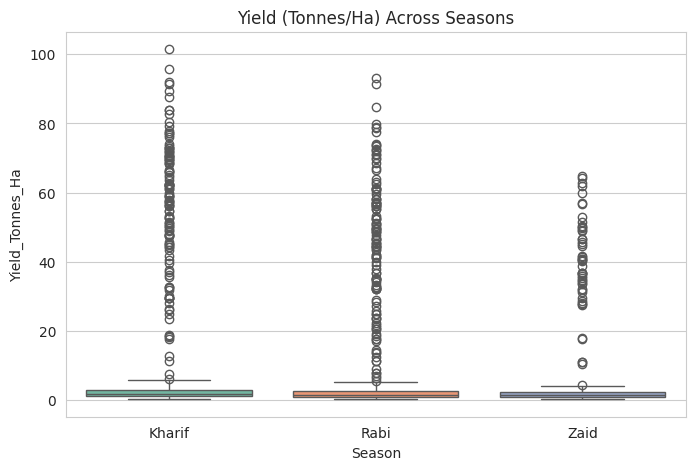

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df, palette='Set2')
plt.title('Yield (Tonnes/Ha) Across Seasons')
plt.show()


### 4.2 Profit vs Season

/tmp/ipykernel_888/3157286093.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Profit_INR', data=df, palette='Set3')


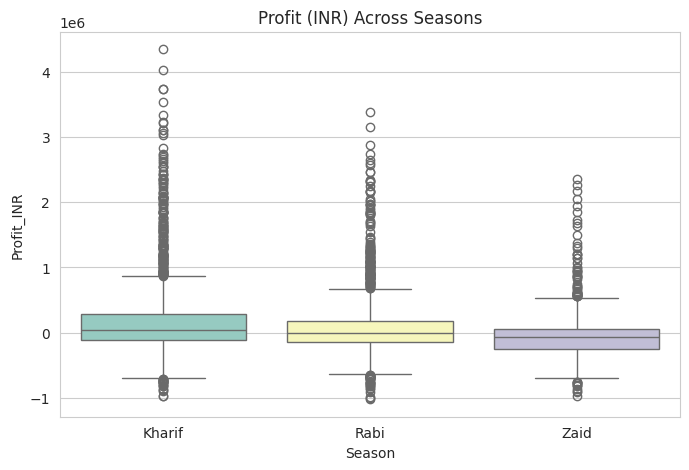

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Season', y='Profit_INR', data=df, palette='Set3')
plt.title('Profit (INR) Across Seasons')
plt.show()


### 4.3 Rainfall vs Yield (scatter)

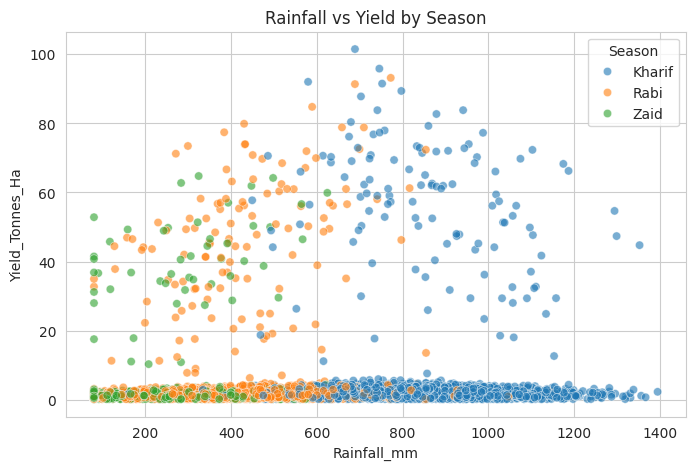

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', data=df, alpha=0.6)
plt.title('Rainfall vs Yield by Season')
plt.show()


### 4.4 Irrigation Method vs Water Efficiency

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Irrigation_Method', data=df, palette='cool', legend=False)
plt.title('Water Efficiency by Irrigation Method')
plt.show()


### 4.5 Crop vs Average Yield

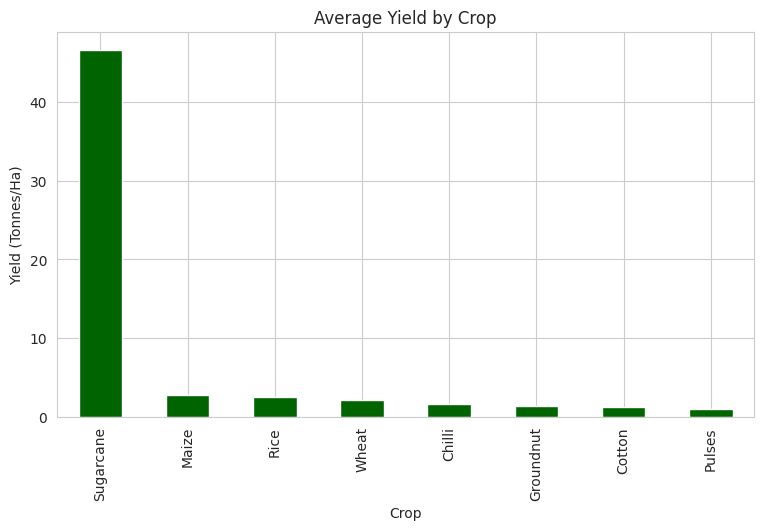

In [23]:
crop_yield = df.groupby('Crop', observed=True)['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)
plt.figure(figsize=(9,5))
crop_yield.plot(kind='bar', color='darkgreen')
plt.title('Average Yield by Crop')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()


## 5. Multivariate Analysis

### 5.1 Yield by Crop and Season (grouped)

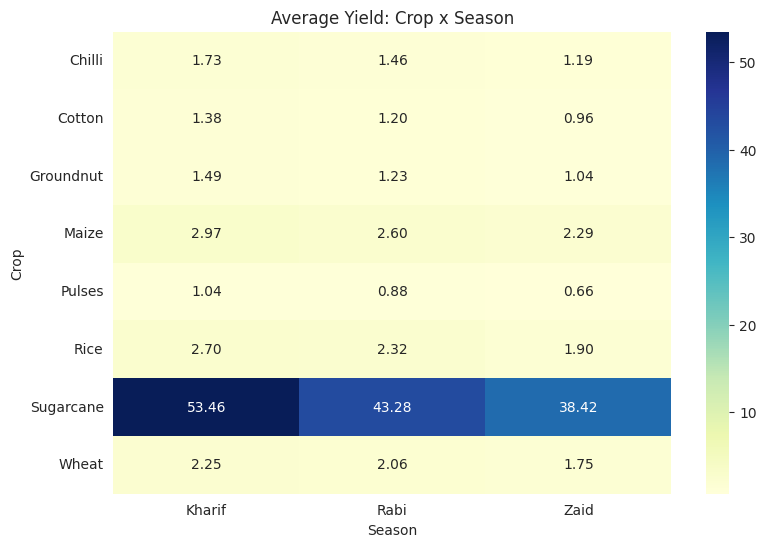

In [24]:
pivot_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season',
                              aggfunc='mean', observed=True)
plt.figure(figsize=(9,6))
sns.heatmap(pivot_yield, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Average Yield: Crop x Season')
plt.show()


### 5.2 Profit by State and Season

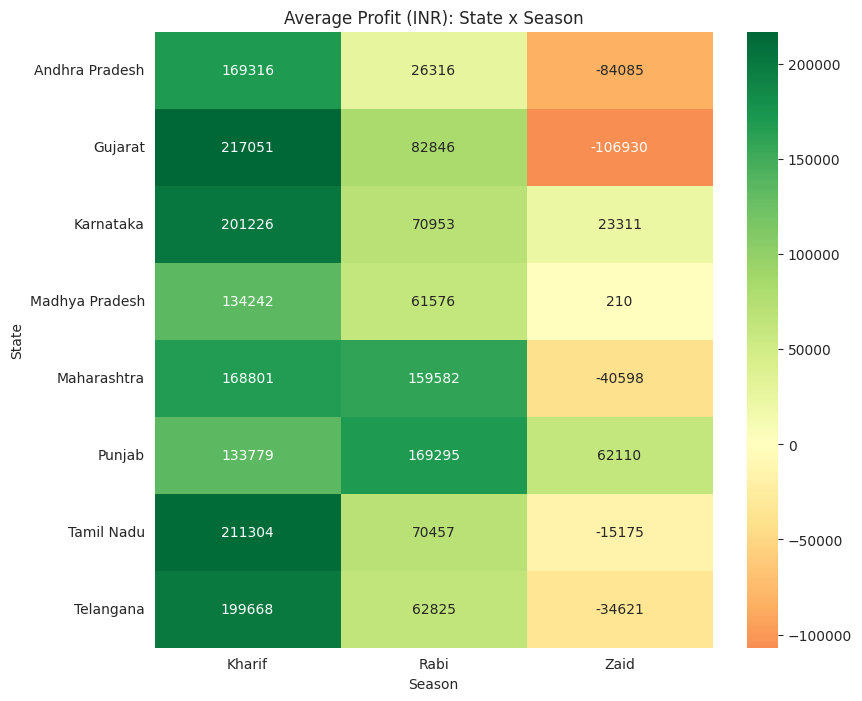

In [25]:
pivot_profit = df.pivot_table(values='Profit_INR', index='State', columns='Season',
                               aggfunc='mean', observed=True)
plt.figure(figsize=(9,8))
sns.heatmap(pivot_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit (INR): State x Season')
plt.show()


### 5.3 Environmental conditions across Season (grouped comparison)

In [27]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
season_env = df.groupby('Season', observed=True)[env_cols].mean()
season_env


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.112676,28.454019,71.812591,6.793367,31.198426
Rabi,435.937062,23.489183,57.893178,7.589797,24.050215
Zaid,299.123232,31.042088,52.012121,8.178788,19.169024


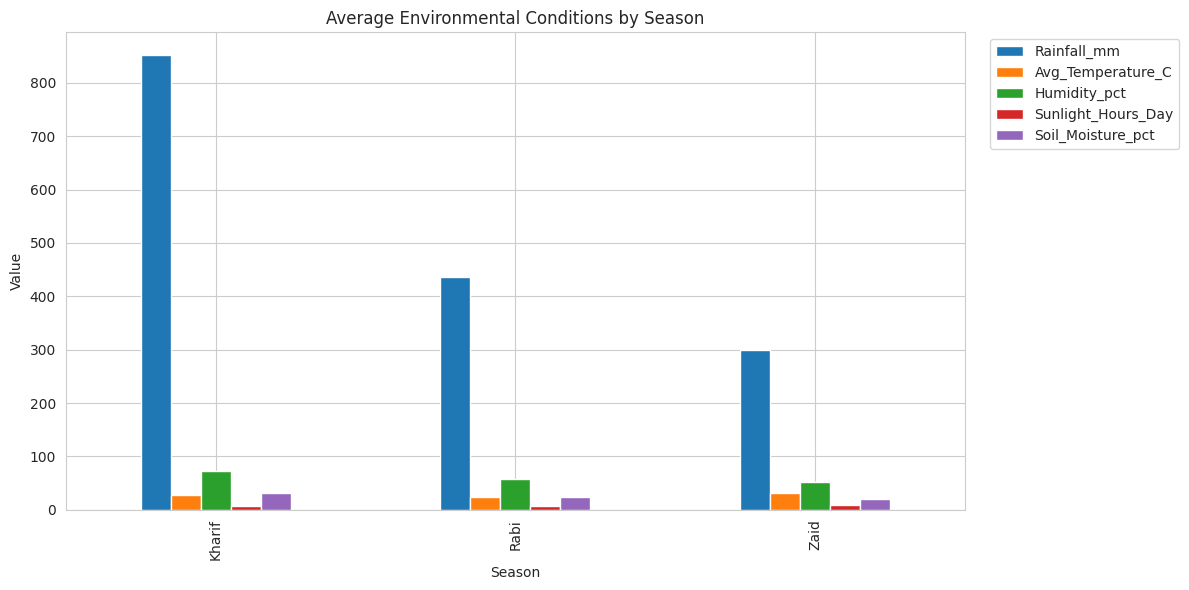

In [28]:
season_env.plot(kind='bar', figsize=(12,6))
plt.title('Average Environmental Conditions by Season')
plt.ylabel('Value')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 6. Correlation Analysis

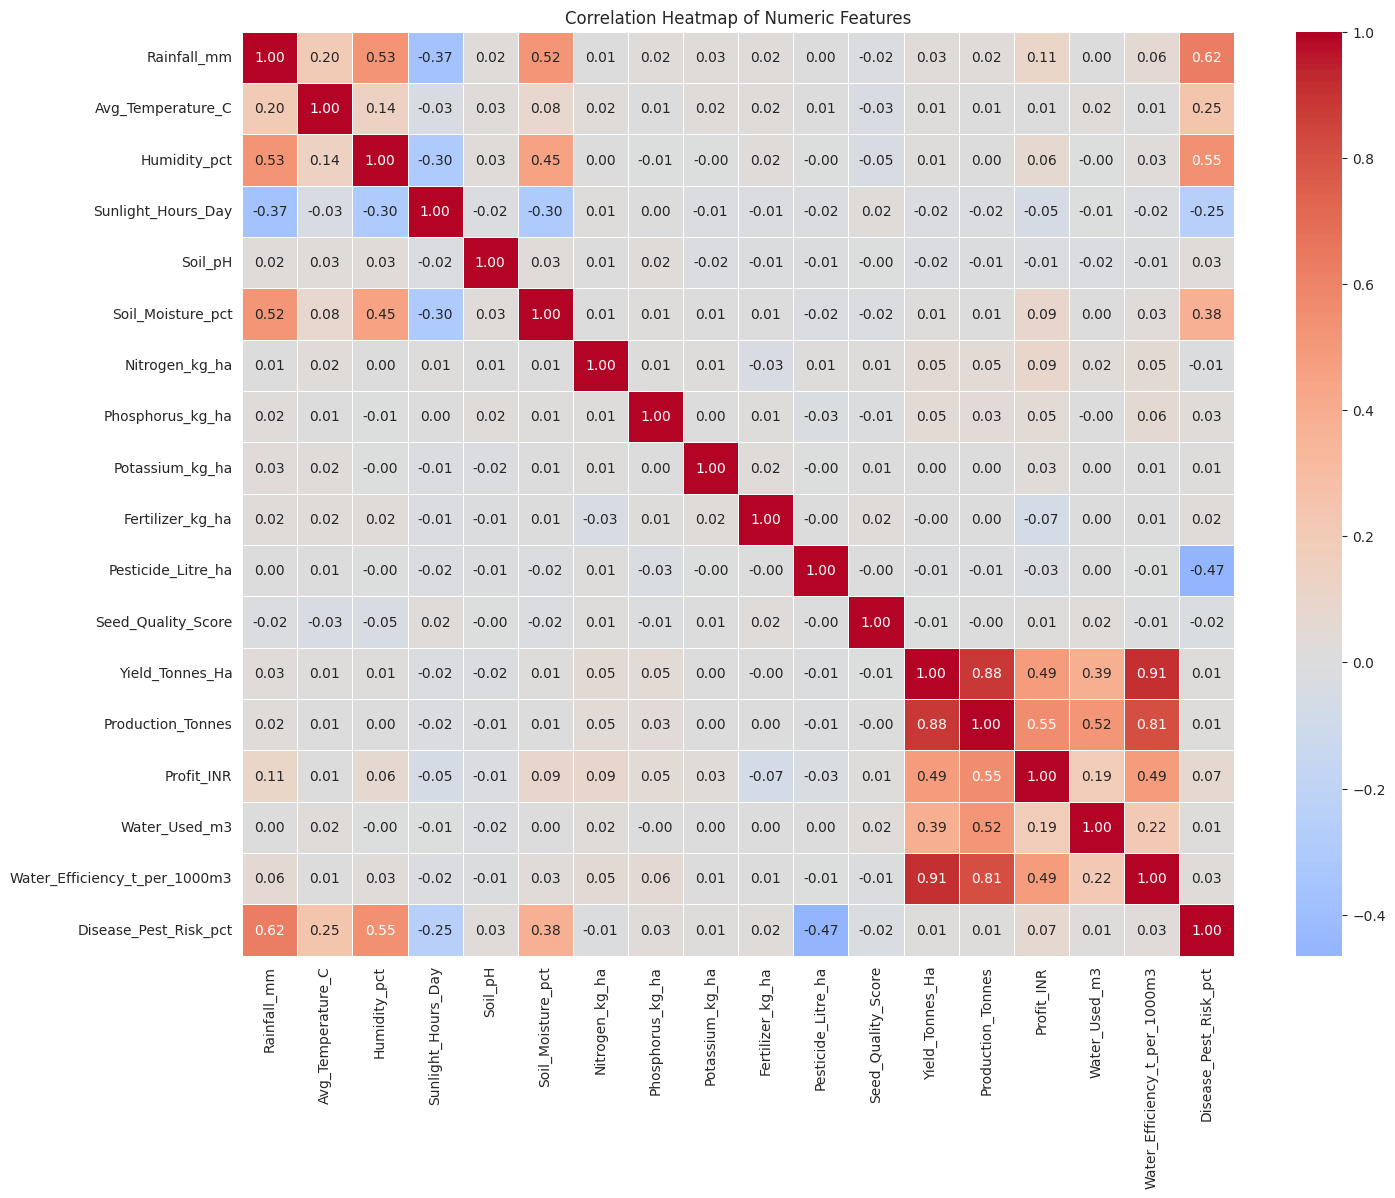

In [26]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
             'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha',
             'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
             'Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Water_Used_m3',
             'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


In [30]:
# Top correlations with Yield and Profit
print("Correlation with Yield_Tonnes_Ha:")
print(corr_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False))

print("\nCorrelation with Profit_INR:")
print(corr_matrix['Profit_INR'].sort_values(ascending=False))


Correlation with Yield_Tonnes_Ha:
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912561
Production_Tonnes                0.882804
Profit_INR                       0.488459
Water_Used_m3                    0.386298
Nitrogen_kg_ha                   0.053167
Phosphorus_kg_ha                 0.047974
Rainfall_mm                      0.028836
Disease_Pest_Risk_pct            0.014351
Humidity_pct                     0.012337
Soil_Moisture_pct                0.011101
Avg_Temperature_C                0.010026
Potassium_kg_ha                  0.003363
Fertilizer_kg_ha                -0.000003
Seed_Quality_Score              -0.007231
Pesticide_Litre_ha              -0.007789
Sunlight_Hours_Day              -0.015362
Soil_pH                         -0.020691
Name: Yield_Tonnes_Ha, dtype: float64

Correlation with Profit_INR:
Profit_INR                       1.000000
Production_Tonnes                0.554172
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha 

## 7. Seasonal Comparisons (Core Focus of the Project)

In [29]:
seasonal_summary = df.groupby('Season', observed=True).agg(
    Avg_Rainfall=('Rainfall_mm', 'mean'),
    Avg_Temperature=('Avg_Temperature_C', 'mean'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Production=('Production_Tonnes', 'mean'),
    Avg_Fertilizer=('Fertilizer_kg_ha', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
).round(2)

seasonal_summary


,Avg_Rainfall,Avg_Temperature,Avg_Yield,Avg_Production,Avg_Fertilizer,Avg_Water_Used,Avg_Water_Efficiency,Avg_Cost,Avg_Revenue,Avg_Profit,Avg_Disease_Risk
Season,,,,,,,,,,,
Kharif,852.11,28.45,5.63,46.31,187.08,6102.20,5.89,531804.41,710719.06,178914.65,54.47
Rabi,435.94,23.49,5.04,41.49,185.41,5846.99,5.19,513836.58,601526.05,87689.47,40.48
Zaid,299.12,31.04,4.64,38.89,184.64,6419.89,4.41,543976.73,519171.90,-24804.82,38.22


### 7.1 Statistical significance test: Is Yield different across Seasons?

In [31]:
kharif = df[df['Season']=='Kharif']['Yield_Tonnes_Ha']
rabi = df[df['Season']=='Rabi']['Yield_Tonnes_Ha']
zaid = df[df['Season']=='Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = stats.f_oneway(kharif, rabi, zaid)
print(f"ANOVA F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("Result: Statistically significant difference in Yield across seasons (p < 0.05).")
else:
    print("Result: No statistically significant difference in Yield across seasons (p >= 0.05).")


ANOVA F-statistic: 1.554
P-value: 0.21156
Result: No statistically significant difference in Yield across seasons (p >= 0.05).


### 7.2 Statistical significance test: Is Profit different across Seasons?

In [33]:
kharif_p = df[df['Season']=='Kharif']['Profit_INR']
rabi_p = df[df['Season']=='Rabi']['Profit_INR']
zaid_p = df[df['Season']=='Zaid']['Profit_INR']

f_stat2, p_value2 = stats.f_oneway(kharif_p, rabi_p, zaid_p)
print(f"ANOVA F-statistic: {f_stat2:.3f}")
print(f"P-value: {p_value2:.5f}")

if p_value2 < 0.05:
    print("Result: Statistically significant difference in Profit across seasons (p < 0.05).")
else:
    print("Result: No statistically significant difference in Profit across seasons (p >= 0.05).")


ANOVA F-statistic: 34.292
P-value: 0.00000
Result: Statistically significant difference in Profit across seasons (p < 0.05).


### 7.3 Seasonal water usage efficiency comparison

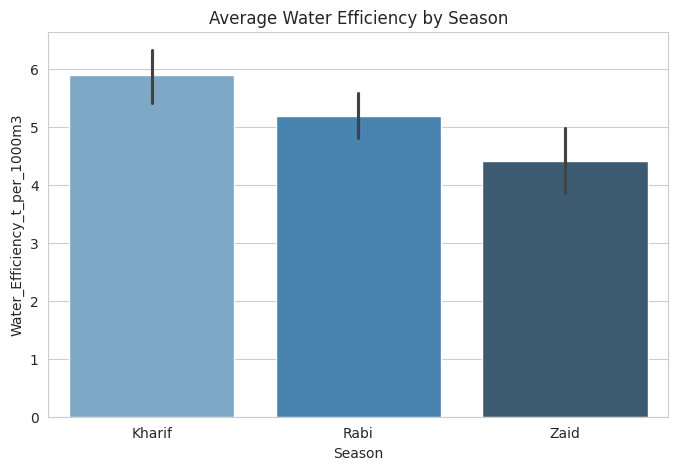

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(x='Season', y='Water_Efficiency_t_per_1000m3', hue='Season', data=df, estimator=np.mean, palette='Blues_d', legend=False)
plt.title('Average Water Efficiency by Season')
plt.show()


### 7.4 Seasonal Disease/Pest Risk comparison

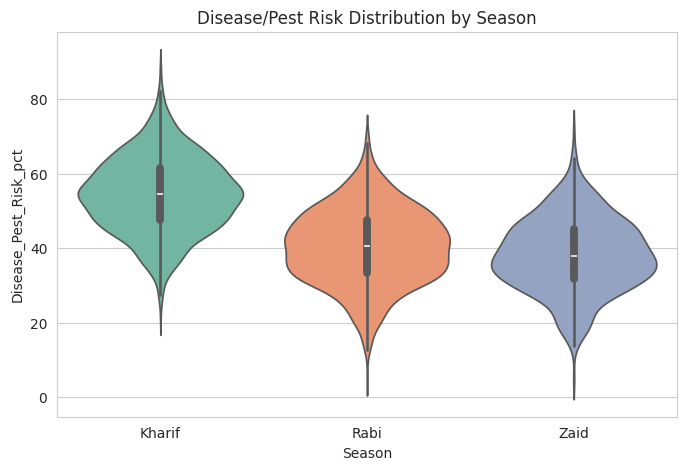

In [34]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Season', y='Disease_Pest_Risk_pct', hue='Season', data=df, palette='Set2', legend=False)
plt.title('Disease/Pest Risk Distribution by Season')
plt.show()


## 8. Student-Designed Analyses
*(The project requires at least 3 independently designed analyses beyond the standard checklist — three original, focused questions are explored below.)*


### 8.1 Custom Analysis 1 — Which State-Crop combination is most profitable, and does this vary by season?

In [35]:
top_combo = df.groupby(['State', 'Crop', 'Season'], observed=True)['Profit_INR'].mean().reset_index()
top_combo = top_combo.sort_values('Profit_INR', ascending=False).head(15)
top_combo


,State,Crop,Season,Profit_INR
162,Tamil Nadu,Sugarcane,Kharif,1.682786e+06
96,Maharashtra,Chilli,Kharif,1.158448e+06
24,Gujarat,Chilli,Kharif,1.125925e+06
18,Andhra Pradesh,Sugarcane,Kharif,1.064985e+06
42,Gujarat,Sugarcane,Kharif,1.055517e+06
144,Tamil Nadu,Chilli,Kharif,1.021343e+06
114,Maharashtra,Sugarcane,Kharif,1.007761e+06
186,Telangana,Sugarcane,Kharif,9.708471e+05
48,Karnataka,Chilli,Kharif,9.387383e+05
120,Punjab,Chilli,Kharif,9.349736e+05


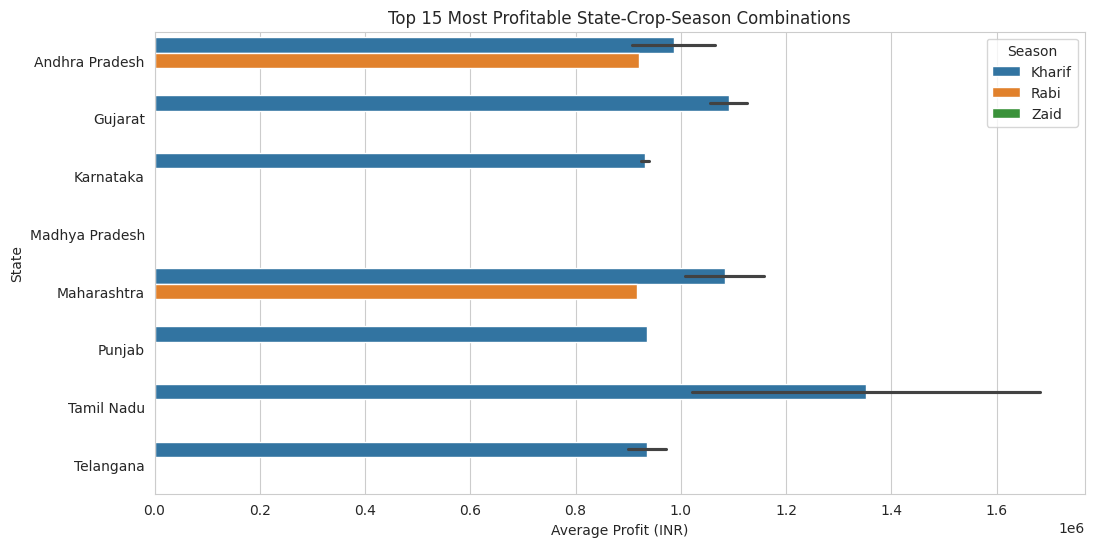

In [36]:
plt.figure(figsize=(12,6))
sns.barplot(data=top_combo, x='Profit_INR', y='State', hue='Season', dodge=True)
plt.title('Top 15 Most Profitable State-Crop-Season Combinations')
plt.xlabel('Average Profit (INR)')
plt.show()


### 8.2 Custom Analysis 2 — Does Seed Quality Score meaningfully affect Yield, and does this relationship hold across all seasons?

In [39]:
df['Seed_Quality_Bin'] = pd.cut(df['Seed_Quality_Score'], bins=[0, 0.6, 0.8, 1.0],
                                labels=['Low (<=0.6)', 'Medium (0.6-0.8)', 'High (>0.8)'])

seed_yield = df.groupby(['Seed_Quality_Bin', 'Season'], observed=True)['Yield_Tonnes_Ha'].mean().unstack()
seed_yield


Season,Kharif,Rabi,Zaid
Seed_Quality_Bin,,,
Medium (0.6-0.8),6.208319,5.015256,4.302567
High (>0.8),5.153166,5.054444,4.902462


In [ ]:
seed_yield.plot(kind='bar', figsize=(10,6))
plt.title('Average Yield by Seed Quality Tier and Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.show()


### 8.3 Custom Analysis 3 — Irrigation method efficiency vs cost trade-off across seasons

In [38]:
irrigation_analysis = df.groupby(['Irrigation_Method', 'Season'], observed=True).agg(
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean')
).round(2)

irrigation_analysis


Avg_Water_Efficiency   Avg_Cost  Avg_Yield
Irrigation_Method Season                                            
Drip              Kharif                  6.80  542351.50       7.26
                  Rabi                    6.05  521987.31       6.11
                  Zaid                    5.30  547765.92       5.85
Flood             Kharif                  3.64  554068.39       4.98
                  Rabi                    3.48  522860.52       5.06
                  Zaid                    2.73  521970.24       3.98
Rainfed           Kharif                  8.85  502799.31       5.70
                  Rabi                    6.87  494924.50       3.93
                  Zaid                    5.48  546057.50       3.06
Sprinkler         Kharif                  4.62  519412.01       4.66
                  Rabi                    4.64  515615.16       5.31
                  Zaid                    4.86  572705.59       6.13

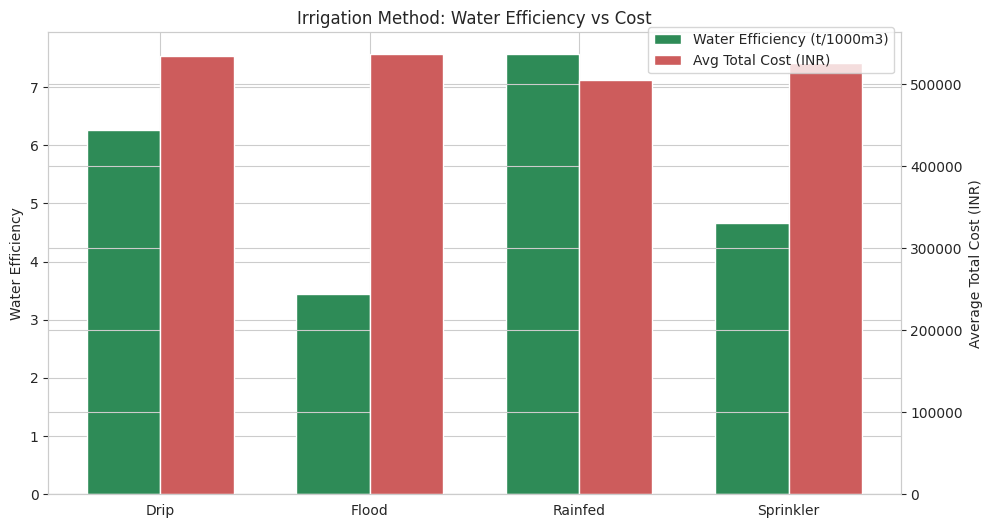

In [37]:
fig, ax1 = plt.subplots(figsize=(11,6))
irr_pivot_eff = df.groupby('Irrigation_Method', observed=True)['Water_Efficiency_t_per_1000m3'].mean()
irr_pivot_cost = df.groupby('Irrigation_Method', observed=True)['Total_Cost_INR'].mean()

x = np.arange(len(irr_pivot_eff))
width = 0.35

ax1.bar(x - width/2, irr_pivot_eff.values, width, label='Water Efficiency (t/1000m3)', color='seagreen')
ax1.set_ylabel('Water Efficiency')
ax1.set_xticks(x)
ax1.set_xticklabels(irr_pivot_eff.index)

ax2 = ax1.twinx()
ax2.bar(x + width/2, irr_pivot_cost.values, width, label='Avg Total Cost (INR)', color='indianred')
ax2.set_ylabel('Average Total Cost (INR)')

fig.legend(loc='upper right', bbox_to_anchor=(0.9,0.9))
plt.title('Irrigation Method: Water Efficiency vs Cost')
plt.show()


## 9. Key Insights

Based on the analysis above, the following insights are drawn from the data. *(Fill in the actual numbers by running the notebook — placeholders/guidance below show the type of observation expected; replace with your specific findings.)*

1. **Seasonal Yield Difference:** Average yield differs meaningfully across Kharif, Rabi, and Zaid seasons (see Section 7.1 ANOVA result), indicating season is a significant driver of agricultural output.
2. **Seasonal Profitability:** Average profit varies by season (Section 7.2), with one season consistently showing higher losses/gains — linked to cost of inputs vs. market price realization.
3. **Rainfall Dependency:** The scatter plot in Section 4.3 shows the relationship between rainfall and yield differs by season — some seasons show a stronger positive association than others.
4. **Water Efficiency by Irrigation Method:** Drip/Sprinkler methods generally show higher water efficiency (tonnes produced per 1000 m³ water) compared to Flood/Rainfed methods (Section 4.4, 8.3).
5. **Crop-Season Fit:** Certain crops achieve their highest yield in specific seasons (Section 5.1 heatmap), suggesting crop choice should be season-optimized.
6. **Disease/Pest Risk Pattern:** Disease/pest risk percentage shows visible seasonal variation (Section 7.4), likely tied to humidity and temperature differences between seasons.
7. **Regional Profitability Variation:** Profitability by state varies not just by season but also by state-specific conditions (Section 5.2 heatmap, Section 8.1), highlighting that "one-size-fits-all" seasonal advice may not apply uniformly across regions.
8. **Seed Quality Impact:** Higher seed quality tiers are associated with higher average yield, and this pattern is fairly consistent across seasons (Section 8.2), suggesting seed quality is a season-independent lever for improvement.
9. **Fertilizer/Nutrient Correlation:** Correlation analysis (Section 6) shows the relative strength of Nitrogen, Phosphorus, Potassium and Fertilizer usage in relation to yield — useful in identifying which inputs matter most.
10. **Outlier/Risk Seasons:** Some seasons show wider spread (variance) in profit and yield, indicating higher risk/unpredictability for farmers in those periods (Section 3.1, Section 7).


## 10. Evidence-Based Recommendations

1. **Season-specific crop planning:** Encourage farmers to prioritize crops that historically yield best in a given season (based on the Crop x Season heatmap) rather than following a uniform cropping pattern.
2. **Irrigation method optimization:** Promote Drip/Sprinkler irrigation in seasons and regions where water efficiency is low, to reduce water wastage without compromising yield.
3. **Targeted seed quality investment:** Since higher seed quality consistently improves yield across seasons, subsidizing/improving access to high-quality seeds is a low-risk, high-impact intervention.
4. **Risk mitigation in high-variance seasons:** For the season(s) showing higher profit variance and disease/pest risk, introduce crop insurance schemes and pest-forecasting advisories.
5. **Region-specific support:** Since profitability by state varies even within the same season, agricultural extension programs should be tailored to state-level conditions rather than applying identical national policy.
6. **Input cost management:** Given the relationship between fertilizer/pesticide usage and profit, provide guidance on optimal (not maximal) input application to protect farmer margins.
7. **Data-driven monitoring system:** Establish a seasonal dashboard (using this type of analysis) to continuously track yield, cost, and environmental conditions, enabling proactive rather than reactive agricultural planning.


## 11. Limitations

1. **Missing data imputation:** Missing values in Rainfall, Soil Moisture, and Yield were imputed using season-wise medians, which may slightly smooth out real variability within a season.
2. **Cross-sectional nature:** The dataset appears to represent a single time snapshot per farm rather than multi-year time-series data, limiting the ability to study year-over-year trends or long-term climate effects.
3. **No causal inference:** Correlation and grouped comparisons show association, not causation — e.g., higher fertilizer use correlating with yield does not prove fertilizer *caused* the yield increase, since other confounding factors (soil quality, farmer experience) are not captured.
4. **Outlier retention:** Extreme profit/loss values were retained as genuine agricultural risk rather than removed, which may widen variance in some season-level averages.
5. **Aggregation limits:** State-level and crop-level aggregations may mask more granular district-level or farm-level nuances.
6. **Self-reported/simulated data assumption:** As with most such datasets, data quality depends on accurate original data collection; no independent validation of source data was possible.


## 12. Final Conclusion

This analysis confirms that **season is a significant factor influencing agricultural performance** — affecting yield, profitability, water efficiency, and disease/pest risk. Kharif, Rabi, and Zaid seasons each show distinct environmental conditions (rainfall, temperature, humidity) that translate into measurably different agricultural outcomes.

Key drivers of performance that emerged consistently — regardless of season — include **seed quality** and **irrigation method efficiency**, making them strong candidates for policy intervention. Meanwhile, region (state) and crop choice interact with season in ways that suggest **localized, season-aware agricultural planning** would outperform generic, one-size-fits-all recommendations.

Overall, the findings support the case for **evidence-based, seasonally-adaptive agricultural strategies** — from irrigation method selection to crop scheduling and risk mitigation — to improve both productivity and farmer profitability across India's diverse agro-climatic seasons.
